Descriptors shape: (676, 128)


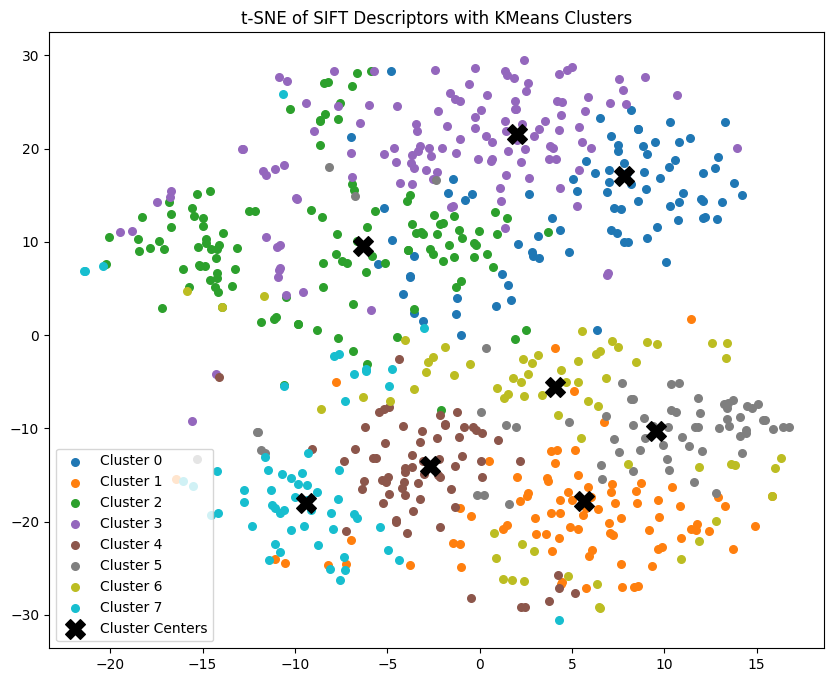

In [22]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# 1. Load image
img = cv2.imread("MainBefore.jpg", cv2.IMREAD_GRAYSCALE)

# 2. Extract SIFT descriptors
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(img, None)

print("Descriptors shape:", descriptors.shape)

# 3. Cluster descriptors with KMeans
k = 8
kmeans = KMeans(n_clusters=k, random_state=0)
assignments = kmeans.fit_predict(descriptors)

# 4. Project descriptors AND cluster centers to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Combine descriptors + cluster centers for joint projection
data_for_tsne = np.vstack([descriptors, kmeans.cluster_centers_])
tsne_result = tsne.fit_transform(data_for_tsne)

# Split back
desc_2d = tsne_result[:len(descriptors)]
centers_2d = tsne_result[len(descriptors):]

# 5. Plot descriptors with cluster assignments
plt.figure(figsize=(10, 8))
colors = plt.cm.tab10(np.linspace(0, 1, k))

for cluster_id in range(k):
    cluster_points = desc_2d[assignments == cluster_id]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                s=30, color=colors[cluster_id], label=f"Cluster {cluster_id}")

# Plot cluster centers
plt.scatter(centers_2d[:, 0], centers_2d[:, 1],
            s=200, c="black", marker="X", label="Cluster Centers")

plt.title("t-SNE of SIFT Descriptors with KMeans Clusters")
plt.legend()
plt.show()


In [23]:
def compute_LAD(descriptors, kmeans):
    k = kmeans.n_clusters
    centers = kmeans.cluster_centers_
    assignments = kmeans.predict(descriptors)

    lad = np.zeros((k, descriptors.shape[1]), dtype=np.float32)

    for i, desc in enumerate(descriptors):
        cluster_id = assignments[i]
        lad[cluster_id] += desc - centers[cluster_id]

    # Flatten & normalize
    lad = lad.flatten()
    lad = lad / np.linalg.norm(lad)
    return lad

lad_vector = compute_LAD(descriptors, kmeans)
print("Final LAD feature vector shape:", lad_vector.shape)


Final LAD feature vector shape: (1024,)
